In [1]:
import os
import numpy as np

from PIL import Image
%load_ext autoreload
%autoreload 2

# Make a dataloader that mixes wevrything randomly loads the images splits a train and test and computes the embeddings
from pathlib import Path

from data_handler import EleHandler
from seek_code import SEEK

import torch
import torch.nn.functional as F
import torchvision.transforms as T
from torch.utils.data import DataLoader
from torch.utils.data.sampler import RandomSampler
import timm


/data/vision/beery/scratch/antoine/micromamba/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def closest_valid_one_hot(prob_vector):
    """
    Converts a probability tensor into the closest valid one-hot encoded representation for each attribute.
    """
    closest_one_hot = []
    index = 0

    for group in SEEK.attribute_names:
        slice_length = SEEK.lengths[group]
        prob_slice = prob_vector[:, index:index + slice_length]
        one_hot_slice = torch.zeros_like(prob_slice)
        
        max_indices = torch.argmax(prob_slice, dim=1)
        one_hot_slice[torch.arange(prob_slice.size(0)), max_indices] = 1.0
        closest_one_hot.append(one_hot_slice)
        
        index += slice_length

    return torch.cat(closest_one_hot, dim=1)

In [3]:
def calculate_attribute_accuracy(predicted, labels):
    # Convert predicted logits to closest valid one-hot representation
    predicted_one_hot = closest_valid_one_hot(predicted)
    
    # Initialize accuracy tracking for all attributes, including individual and averaged
    accuracies = {name: 0 for name in SEEK.attribute_names}

    index = 0
    for name in SEEK.attribute_names:
        length = SEEK.lengths[name]
        pred_slice = predicted_one_hot[:, index:index + length]
        label_slice = labels[:, index:index + length]

        # Calculate per-sample accuracy
        pred_indices = torch.argmax(pred_slice, dim=1)
        label_indices = torch.argmax(label_slice, dim=1)
        accuracies[name] = (pred_indices == label_indices).float().mean().item()

        index += length

    # Include accuracy for whole SEEK code prediction
    correct_whole_code = torch.all(predicted_one_hot == labels, dim=1).float().mean().item()
    accuracies['average'] = sum(accuracies.values()) / len(accuracies)
    accuracies['whole_code'] = correct_whole_code

    return accuracies


In [4]:
def epoch_pass(epoch, loader, training=True):
    model.eval()  # Freeze model for inference
    layer.train() if training else layer.eval()

    total_loss = 0
    num_batches = len(loader)
    epoch_accuracies = {name: 0 for name in SEEK.attribute_names}
    epoch_accuracies['average'] = 0
    epoch_accuracies['whole_code'] = 0

    for batch in loader:
        images, subject_id, ele_id, identified, subject_SEEK, ele_SEEK = batch[:6]

        # Prepare labels and transfer them to GPU
        images = images.to('cuda')
        labels = torch.stack([SEEK(s).one_hot_encode() for s in subject_SEEK]).to('cuda')

        # Obtain embeddings from the frozen model
        with torch.no_grad():
            embeddings = model(images)

        # Forward pass through the trainable layer
        outputs = layer(embeddings)
        
        # Calculate loss
        loss = F.mse_loss(outputs, labels)
        total_loss += loss.item()

        # Calculate accuracy for average and whole-code
        predicted_SEEK = closest_valid_one_hot(outputs)
        batch_accuracies = calculate_attribute_accuracy(predicted_SEEK, labels)
        
        for name, value in batch_accuracies.items():            
            epoch_accuracies[name] += value

        # Backpropagation only for the linear layer if training
        if training:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # Calculate epoch-level average loss and accuracies
    average_loss = total_loss / num_batches
    epoch_accuracies = {name: accuracy / num_batches for name, accuracy in epoch_accuracies.items()}
    
    return average_loss, epoch_accuracies


In [5]:
def train_concept_head(train_loader, val_loader, backbone_frozen=True, num_epochs=10):
    """
    Trains a linear layer on top of a pre-trained model to predict SEEK codes.
    """
    for epoch in range(num_epochs):
        train_loss, train_acc = epoch_pass(epoch, train_loader, training=True)
        val_loss, val_acc = epoch_pass(epoch, val_loader, training=False)
        
        if epoch % 5 == 0:
            print(f" Epoch {epoch + 1}/{num_epochs} - Loss : train {train_loss:.4f} val {val_loss:.4f} - Avg accuracy : train {train_acc['average'] * 100:.2f}% val {val_acc['average'] * 100:.2f}% - Whole Code : train {train_acc['whole_code'] * 100:.2f}% val {val_acc['whole_code'] * 100:.2f}%")
    return train_loss, train_acc['average'], train_acc['whole_code'], val_loss, val_acc['average'], val_acc['whole_code']

def test_concept_head(test_loader):

    test_loss, test_acc = epoch_pass(-1, test_loader, training=False)
    
    print("============ Test Summary =========== ")
    print(f"  Test Loss: {test_loss:.4f}")

    # Detailed accuracy for each characteristic
    print("\nDetailed Characteristic Accuracies:")
    for name, value in test_acc.items():
        print(f"  {name} Accuracy: {value * 100:.2f}%")
    
    return test_loss, test_acc['average'], test_acc['whole_code'], test_acc


### Comparing the backbones, lin prob (no sigmoid yet)

In [6]:
# Create dataset and dataloaders
dataset = EleHandler( )

train_indices, val_indices, test_indices = dataset.split_along_encounters([0.7,0.15,0.15])

train_loader, val_loader, test_loader = (DataLoader(dataset, batch_size=512, sampler=RandomSampler(indices), num_workers=4) for indices in [train_indices, val_indices, test_indices])

model = timm.create_model("hf-hub:BVRA/MegaDescriptor-T-224", pretrained=True, num_classes=0) # Mega-Descriptor pretrained
#state_dict = torch.load("../weights/forest_elephants-reid_weights.pt", map_location='cuda') # Pretrained on forest elephants
state_dict = torch.load("../weights/savanna_elephants_md_v2_epoch_60.pt", map_location='cuda') # Pretrained on savannah elephants
model.load_state_dict(state_dict["model"]) if "optimizer" in state_dict else model.load_state_dict(state_dict)
model.to('cuda')

layer = torch.nn.Linear(768, 63).to('cuda')

optimizer = torch.optim.Adam(layer.parameters(), lr=0.001)

train_concept_head(train_loader, val_loader, backbone_frozen = True,  num_epochs=50)
test_concept_head(test_loader)

Train indices: 6108, Validation indices: 1101, Test indices: 1235


/tmp/ipykernel_2458467/3952646767.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load("../weights/savanna_elephants_md_v2_epoch_60.pt", map_location

KeyboardInterrupt: 

In [13]:
# Create dataset and dataloaders
dataset = EleHandler( )

train_indices, val_indices, test_indices = dataset.split_along_encounters([0.7,0.15,0.15])

train_loader, val_loader, test_loader = (DataLoader(dataset, batch_size=1024, sampler=RandomSampler(indices), num_workers=4) for indices in [train_indices, val_indices, test_indices])

model = timm.create_model("hf-hub:BVRA/MegaDescriptor-T-224", pretrained=True, num_classes=0) # Mega-Descriptor pretrained
state_dict = torch.load("../weights/forest_elephants-reid_weights.pt", map_location='cuda') # Pretrained on forest elephants
#state_dict = torch.load("../weights/savanna_elephants_md_v2_epoch_60.pt", map_location='cuda') # Pretrained on savannah elephants
model.load_state_dict(state_dict["model"]) if "optimizer" in state_dict else model.load_state_dict(state_dict)
model.to('cuda')

layer = torch.nn.Linear(768, 63).to('cuda')

optimizer = torch.optim.Adam(layer.parameters(), lr=0.001)

train_concept_head(train_loader, val_loader, backbone_frozen = True,  num_epochs=50)
test_concept_head(test_loader)

Train indices: 6108, Validation indices: 1101, Test indices: 1235


/tmp/ipykernel_1503260/2603901186.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load("../weights/forest_elephants-reid_weights.pt", map_location='cu

 Epoch 1/50 - Loss : train 0.2968 val 0.2345 - Avg accuracy : train 48.23% val 61.72% - Whole Code : train 0.05% val 0.00%
 Epoch 6/50 - Loss : train 0.1315 val 0.1287 - Avg accuracy : train 69.26% val 69.57% - Whole Code : train 1.15% val 0.73%
 Epoch 11/50 - Loss : train 0.1122 val 0.1107 - Avg accuracy : train 71.83% val 72.02% - Whole Code : train 2.20% val 1.07%
 Epoch 16/50 - Loss : train 0.1047 val 0.1048 - Avg accuracy : train 73.25% val 73.55% - Whole Code : train 3.52% val 2.07%
 Epoch 21/50 - Loss : train 0.1003 val 0.1017 - Avg accuracy : train 74.04% val 74.09% - Whole Code : train 4.09% val 5.46%
 Epoch 26/50 - Loss : train 0.0975 val 0.0947 - Avg accuracy : train 74.55% val 75.69% - Whole Code : train 4.56% val 6.21%
 Epoch 31/50 - Loss : train 0.0955 val 0.0959 - Avg accuracy : train 74.93% val 75.18% - Whole Code : train 4.84% val 3.64%
 Epoch 36/50 - Loss : train 0.0937 val 0.0920 - Avg accuracy : train 75.28% val 76.14% - Whole Code : train 5.23% val 4.89%
 Epoch 41/

(0.09069286659359932,
 0.756752498447895,
 0.04581281542778015,
 {'sex': 0.9351581335067749,
  'age': 0.9336215257644653,
  'right_tusk': 0.7708202302455902,
  'left_tusk': 0.8496649265289307,
  'R_tear_1': 0.4723901301622391,
  'R_hole_1': 0.7141934931278229,
  'R_tear_2': 0.6227969527244568,
  'R_hole_2': 0.800864577293396,
  'L_tear_1': 0.4490521401166916,
  'L_hole_1': 0.7374736368656158,
  'L_tear_2': 0.5988711714744568,
  'L_hole_2': 0.8230964243412018,
  'right_extreme': 0.823325514793396,
  'left_extreme': 0.8147516548633575,
  'ear_special': 0.8523215651512146,
  'body_special': 0.9096378982067108,
  'average': 0.756752498447895,
  'whole_code': 0.04581281542778015})

In [14]:
# Create dataset and dataloaders
dataset = EleHandler( )

train_indices, val_indices, test_indices = dataset.split_along_encounters([0.7,0.15,0.15])

train_loader, val_loader, test_loader = (DataLoader(dataset, batch_size=1024, sampler=RandomSampler(indices), num_workers=4) for indices in [train_indices, val_indices, test_indices])

model = timm.create_model("hf-hub:BVRA/MegaDescriptor-T-224", pretrained=True, num_classes=0) # Mega-Descriptor pretrained
#state_dict = torch.load("../weights/forest_elephants-reid_weights.pt", map_location='cuda') # Pretrained on forest elephants
state_dict = torch.load("../weights/savanna_elephants_md_v2_epoch_60.pt", map_location='cuda') # Pretrained on savannah elephants
model.load_state_dict(state_dict["model"]) if "optimizer" in state_dict else model.load_state_dict(state_dict)
model.to('cuda')

layer = torch.nn.Linear(768, 63).to('cuda')

optimizer = torch.optim.Adam(layer.parameters(), lr=0.001)

train_concept_head(train_loader, val_loader, backbone_frozen = True,  num_epochs=50)
test_concept_head(test_loader)

Train indices: 6108, Validation indices: 1101, Test indices: 1235


/tmp/ipykernel_1503260/398986641.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load("../weights/savanna_elephants_md_v2_epoch_60.pt", map_location=

 Epoch 1/50 - Loss : train 0.2875 val 0.2042 - Avg accuracy : train 44.49% val 64.32% - Whole Code : train 0.02% val 0.20%
 Epoch 6/50 - Loss : train 0.1297 val 0.1273 - Avg accuracy : train 68.68% val 68.65% - Whole Code : train 0.98% val 0.44%
 Epoch 11/50 - Loss : train 0.1116 val 0.1097 - Avg accuracy : train 71.49% val 72.17% - Whole Code : train 2.04% val 4.17%
 Epoch 16/50 - Loss : train 0.1044 val 0.1053 - Avg accuracy : train 72.74% val 72.34% - Whole Code : train 2.83% val 1.92%
 Epoch 21/50 - Loss : train 0.1002 val 0.1012 - Avg accuracy : train 73.55% val 72.99% - Whole Code : train 3.76% val 2.86%
 Epoch 26/50 - Loss : train 0.0974 val 0.0969 - Avg accuracy : train 74.10% val 74.04% - Whole Code : train 4.37% val 5.05%
 Epoch 31/50 - Loss : train 0.0956 val 0.0951 - Avg accuracy : train 74.42% val 74.26% - Whole Code : train 4.85% val 3.71%
 Epoch 36/50 - Loss : train 0.0940 val 0.0913 - Avg accuracy : train 74.72% val 76.16% - Whole Code : train 5.22% val 5.65%
 Epoch 41/

(0.0936911553144455,
 0.7462517041712999,
 0.057101137936115265,
 {'sex': 0.940802276134491,
  'age': 0.936896026134491,
  'right_tusk': 0.7865748405456543,
  'left_tusk': 0.8360786736011505,
  'R_tear_1': 0.49608680605888367,
  'R_hole_1': 0.6957822740077972,
  'R_tear_2': 0.6197816431522369,
  'R_hole_2': 0.7963983118534088,
  'L_tear_1': 0.46179142594337463,
  'L_hole_1': 0.6727173626422882,
  'L_tear_2': 0.5442831814289093,
  'L_hole_2': 0.765865683555603,
  'right_extreme': 0.8204536736011505,
  'left_extreme': 0.8177253305912018,
  'ear_special': 0.8353890776634216,
  'body_special': 0.9134006798267365,
  'average': 0.7462517041712999,
  'whole_code': 0.057101137936115265})

### Adding a sigmoid

In [ ]:

# Create dataset and dataloaders
dataset = EleHandler( )

train_indices, val_indices, test_indices = dataset.split_along_encounters([0.7,0.15,0.15], hour_delta=2)

train_loader, val_loader, test_loader = (DataLoader(dataset, batch_size=1024, sampler=RandomSampler(indices), num_workers=4) for indices in [train_indices, val_indices, test_indices])


model = timm.create_model("hf-hub:BVRA/MegaDescriptor-T-224", pretrained=True, num_classes=0) # Mega-Descriptor pretrained
#state_dict = torch.load("../weights/forest_elephants-reid_weights.pt", map_location='cuda') # Pretrained on forest elephants
state_dict = torch.load("../weights/savanna_elephants_md_v2_epoch_60.pt", map_location='cuda') # Pretrained on savannah elephants
model.load_state_dict(state_dict["model"]) if "optimizer" in state_dict else model.load_state_dict(state_dict)
model.to('cuda')

layer = torch.nn.Sequential(
    torch.nn.Linear(768, 63),
    torch.nn.Sigmoid()
).to('cuda')

optimizer = torch.optim.Adam(layer.parameters(), lr=0.001)

train_concept_head(train_loader, val_loader, backbone_frozen = True,  num_epochs=50)
test_concept_head(test_loader)

Train indices: 5862, Validation indices: 1302, Test indices: 1280


/tmp/ipykernel_3981539/3467429344.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load("../weights/savanna_elephants_md_v2_epoch_60.pt", map_location

 Epoch 1/50 - Loss : train 0.1903 val 0.1333 - Avg accuracy : train 52.56% val 66.63% - Whole Code : train 0.03% val 0.62%
 Epoch 6/50 - Loss : train 0.1076 val 0.1079 - Avg accuracy : train 69.42% val 69.36% - Whole Code : train 1.40% val 1.31%
 Epoch 11/50 - Loss : train 0.1027 val 0.1034 - Avg accuracy : train 71.17% val 71.00% - Whole Code : train 2.69% val 2.58%
 Epoch 16/50 - Loss : train 0.0999 val 0.1032 - Avg accuracy : train 72.25% val 71.19% - Whole Code : train 3.52% val 3.36%
 Epoch 21/50 - Loss : train 0.0980 val 0.0981 - Avg accuracy : train 72.89% val 73.14% - Whole Code : train 4.06% val 4.21%
 Epoch 26/50 - Loss : train 0.0966 val 0.0977 - Avg accuracy : train 73.35% val 73.36% - Whole Code : train 4.51% val 4.46%
 Epoch 31/50 - Loss : train 0.0955 val 0.0967 - Avg accuracy : train 73.75% val 73.59% - Whole Code : train 4.82% val 4.29%
 Epoch 36/50 - Loss : train 0.0944 val 0.0969 - Avg accuracy : train 74.09% val 73.35% - Whole Code : train 5.11% val 4.36%
 Epoch 41/

(0.09372416511178017,
 0.7451171875,
 0.05419921875,
 {'sex': 0.939453125,
  'age': 0.9326171875,
  'right_tusk': 0.7958984375,
  'left_tusk': 0.85595703125,
  'R_tear_1': 0.453125,
  'R_hole_1': 0.6748046875,
  'R_tear_2': 0.60302734375,
  'R_hole_2': 0.7841796875,
  'L_tear_1': 0.478515625,
  'L_hole_1': 0.68994140625,
  'L_tear_2': 0.5654296875,
  'L_hole_2': 0.77294921875,
  'right_extreme': 0.81298828125,
  'left_extreme': 0.794921875,
  'ear_special': 0.85595703125,
  'body_special': 0.912109375,
  'average': 0.7451171875,
  'whole_code': 0.05419921875})

# Trying implementing the ears

In [9]:
import random
dataset = EleHandler( )

ear_detector = torch.hub.load("ultralytics/yolov5", "custom", path='/data/vision/beery/scratch/antoine/CBM_reid/weights/ear_YOLOv5_n.pt')

# Choose a random index from the dataset
idx = random.choice(range(len(dataset)))
dataset = EleHandler()
image = dataset.get_original_image(idx)

# inger the model to find the ears
output = ear_detector(dataset.get_original_image(idx))
print('found ', len(output.pred[0].tolist()), ' ears')


# Extract the side of the ears (left or right) from output
ear_sides = [output.names[int(det[-1])] for det in output.pred[0].tolist()]
print('Ear sides:', ear_sides)


xyxy = output.xyxy[0].tolist()

cropped_ears = [None] * len(xyxy)

print(output)

display(image)

for i in range(len(xyxy)):
    print('ear #', i+1)
    cropped_ears[i] = image.crop(tuple(xyxy[i][:4]))
    cropped_ears[i] = cropped_ears[i].resize((cropped_ears[i].width // 2, cropped_ears[i].height // 2))
    display(cropped_ears[i])

Using cache found in /data/vision/beery/scratch/antoine/.cache/torch/hub/ultralytics_yolov5_master
YOLOv5 🚀 2024-11-18 Python-3.13.0 torch-2.5.1.post302 CUDA:0 (NVIDIA A100-SXM4-80GB, 81038MiB)



Exception: CUDA error: out of memory
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.
. Cache may be out of date, try `force_reload=True` or see https://docs.ultralytics.com/yolov5/tutorials/pytorch_hub_model_loading for help.

/data/vision/beery/scratch/antoine/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:892: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


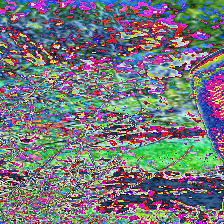

right


In [10]:
def crop_ears(original_image):
    '''
    Input : a non-transformed image
    Output : a list of two cropped ears, resized to 224x224, normalized to be embedded
    '''
    with torch.inference_mode():
        # infer with the ear detector (a pre-trained YOLOv5 model)
        output = ear_detector(original_image)

        # extract the bounding boxes of the detected ears
        xyxy = output.xyxy[0].tolist()

        # Extract the side of the ears (left or right) from output
        ear_sides = [output.names[int(det[-1])] for det in output.pred[0].tolist()]

        cropped_ears = [None] * len(xyxy)  

        # Go over the detected ears, crop them and transform them to a normalized tenser
        for j in range(min(len(xyxy),2)):            
            cropped_ears[j]= T.Compose([
                    T.Lambda(lambda img: img.crop(tuple(xyxy[j][:4]))),
                    T.Resize([224, 224]),
                    T.ToTensor(),
                    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
                ])(original_image)

        # Matching the ears to the correct side
        left_ear, right_ear = None, None
        for i, side in enumerate(ear_sides):
            if side == "left":
                left_ear = cropped_ears[i]
            elif side == "right":
                right_ear = cropped_ears[i]

    return left_ear, right_ear

# test
original_image = dataset.get_original_image(random.choice(range(len(dataset))))
left_ear, right_ear = crop_ears(original_image)

if left_ear is not None: 
    display(T.ToPILImage()(left_ear))
    print('left')
if right_ear is not None: 
    display(T.ToPILImage()(right_ear))
    print('right')

In [7]:
def epoch_pass_with_ears(epoch, loader, training=True):
    model.eval()  # Freeze model for inference
    layer.train() if training else layer.eval()

    total_loss = 0
    num_batches = len(loader)
    epoch_accuracies = {name: 0 for name in SEEK.attribute_names}
    epoch_accuracies['average'] = 0
    epoch_accuracies['whole_code'] = 0
    
    for batch in loader:
        images, subject_id, ele_id, identified, subject_SEEK, ele_SEEK, left_ears, right_ears = batch[:8]

        # Embbed the ears and the whole images
        with torch.no_grad():
            images = images.to('cuda')
            left_ears = left_ears.to('cuda')
            right_ears = right_ears.to('cuda')

            embeddings = model(images)
            left_embeddings = model(left_ears)
            right_embeddings = model(right_ears)
            
            # Concatenate the embeddings
            total_embeddings = torch.cat((embeddings, left_embeddings, right_embeddings), dim=1)


        # Forward pass through the trainable layer
        outputs = layer(total_embeddings)

        # Prepare labels and transfer them to GPU
        labels = torch.stack([SEEK(s).one_hot_encode() for s in subject_SEEK]).to('cuda')
        
        # Calculate loss
        loss = F.mse_loss(outputs, labels)
        total_loss += loss.item()

        # Calculate accuracy for average and whole-code
        predicted_SEEK = closest_valid_one_hot(outputs)
        batch_accuracies = calculate_attribute_accuracy(predicted_SEEK, labels)
        
        for name, value in batch_accuracies.items():            
            epoch_accuracies[name] += value

        # Backpropagation only for the linear layer if training
        if training:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # Calculate epoch-level average loss and accuracies
    average_loss = total_loss / num_batches
    epoch_accuracies = {name: accuracy / num_batches for name, accuracy in epoch_accuracies.items()}
    
    return average_loss, epoch_accuracies

def train_concept_head_with_ears(train_loader, val_loader, backbone_frozen=True, num_epochs=10):
    """
    Trains a linear layer on top of a pre-trained model to predict SEEK codes.
    """
    for epoch in range(num_epochs):
        train_loss, train_acc = epoch_pass_with_ears(epoch, train_loader, training=True)
        val_loss, val_acc = epoch_pass_with_ears(epoch, val_loader, training=False)
        
        if epoch % 1 == 0:
            print(f" Epoch {epoch + 1}/{num_epochs} - Loss : train {train_loss:.4f} val {val_loss:.4f} - Avg accuracy : train {train_acc['average'] * 100:.2f}% val {val_acc['average'] * 100:.2f}% - Whole Code : train {train_acc['whole_code'] * 100:.2f}% val {val_acc['whole_code'] * 100:.2f}%")
    return train_loss, train_acc['average'], train_acc['whole_code'], val_loss, val_acc['average'], val_acc['whole_code']


def test_concept_head_with_ears(test_loader):

    test_loss, test_acc = epoch_pass_with_ears(-1, test_loader, training=False)
    
    print("============ Test Summary =========== ")
    print(f"  Test Loss: {test_loss:.4f}")

    # Detailed accuracy for each characteristic
    print("\nDetailed Characteristic Accuracies:")
    for name, value in test_acc.items():
        print(f"  {name} Accuracy: {value * 100:.2f}%")
    
    return test_loss, test_acc['average'], test_acc['whole_code'], test_acc


import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [9]:
# Create dataset and dataloaders
dataset = EleHandler()

#train_indices, val_indices, test_indices = dataset.split_along_encounters([0.7,0.15,0.15], hour_delta=2)
from torch.utils.data import DataLoader, SubsetRandomSampler
import numpy as np

# Create Random loader
indices = np.random.permutation(len(dataset))
train_split, val_split = int(0.7 * len(dataset)), int(0.15 * len(dataset))
train_loader = DataLoader(dataset, batch_size=128, sampler=SubsetRandomSampler(indices[:train_split]), num_workers=4)
val_loader = DataLoader(dataset, batch_size=128, sampler=SubsetRandomSampler(indices[train_split:train_split + val_split]), num_workers=4)
test_loader = DataLoader(dataset, batch_size=128, sampler=SubsetRandomSampler(indices[train_split + val_split:]), num_workers=4)

# Create loaders along encounters
train_indices, val_indices, test_indices = dataset.split_along_encounters([0.7,0.15,0.15], hour_delta=2)
train_loader, val_loader, test_loader = (DataLoader(dataset, batch_size=1024, sampler=RandomSampler(indices), num_workers=4) for indices in [train_indices, val_indices, test_indices])

model = timm.create_model("hf-hub:BVRA/MegaDescriptor-T-224", pretrained=True, num_classes=0) # Mega-Descriptor pretrained
#state_dict = torch.load("../weights/forest_elephants-reid_weights.pt", map_location='cuda') # Pretrained on forest elephants
state_dict = torch.load("../weights/savanna_elephants_md_v2_epoch_60.pt", map_location='cuda') # Pretrained on savannah elephants
model.load_state_dict(state_dict["model"]) if "optimizer" in state_dict else model.load_state_dict(state_dict)
model.to('cuda')

layer = torch.nn.Sequential(
    torch.nn.Linear(2304, 63),
    torch.nn.Sigmoid()
).to('cuda')


optimizer = torch.optim.Adam(layer.parameters(), lr=0.001)

train_concept_head_with_ears(train_loader, val_loader, backbone_frozen = True,  num_epochs=200)
test_concept_head_with_ears(test_loader)

# Save the trained model weights
torch.save(layer.state_dict, 'trained_model_with_ears.pth')

Train indices: 5862, Validation indices: 1302, Test indices: 1280


/tmp/ipykernel_1319157/3836642806.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load("../weights/savanna_elephants_md_v2_epoch_60.pt", map_location

RuntimeError: DataLoader worker (pid(s) 1927051) exited unexpectedly

In [118]:
def predict_all(dataset):
    
    accumulate_images = []
    accumulate_embeddings = []
    accumulate_predictions = []
    accumulate_labels = []
    accumulate_outputs = []

    dataloader = DataLoader(dataset, batch_size=512, shuffle=False, num_workers=4)

    for images, subject_id, ele_id, identified, subject_SEEK, ele_SEEK, left_ears, right_ears in dataloader:
               # Embbed the ears and the whole images
        with torch.no_grad():
            images = images.to('cuda')
            left_ears = left_ears.to('cuda')
            right_ears = right_ears.to('cuda')

            embeddings = model(images)
            left_embeddings = model(left_ears)
            right_embeddings = model(right_ears)
            
            # Concatenate the embeddings
            total_embeddings = torch.cat((embeddings, left_embeddings, right_embeddings), dim=1)

            # Forward pass through the trainable layer
            outputs = layer(total_embeddings)   
            predicted_SEEK = closest_valid_one_hot(outputs)
            
            subject_SEEK = torch.stack([SEEK(s).one_hot_encode() for s in subject_SEEK]).to('cuda')

            accumulate_embeddings.append(total_embeddings.cpu())
            accumulate_predictions.append(predicted_SEEK.cpu())
            accumulate_images.append(images.cpu())
            accumulate_labels.append(subject_SEEK)
            accumulate_outputs.append(outputs.cpu())

    accumulate_images = torch.cat(accumulate_images, dim=0)
    accumulate_embeddings = torch.cat(accumulate_embeddings, dim=0)
    accumulate_predictions = torch.cat(accumulate_predictions, dim=0)
    accumulate_labels = torch.cat(accumulate_labels, dim=0)
    accumulate_outputs = torch.cat(accumulate_outputs, dim=0)

    return accumulate_images, accumulate_embeddings, accumulate_predictions, accumulate_labels, accumulate_outputs

In [119]:
from collections import Counter

dataset = EleHandler()
images, embeddings, predictions, labels, outputs = predict_all(dataset)


In [120]:

predictions_S =[SEEK(p) for p in predictions]

# Dictionary to store counts for each attribute
attribute_counts = {attribute: Counter() for attribute in SEEK.attribute_names}

# Iterate over all predictions and count attribute values
for seek_obj in predictions_S:
    for attribute in SEEK.attribute_names:
        attribute_value = getattr(seek_obj, attribute)  # Get the value of the attribute
        attribute_counts[attribute][attribute_value] += 1

# Display results
for attribute, counts in attribute_counts.items():
    print(f"Attribute: {attribute}")
    for value, count in counts.items():
        print(f"  Value {value}: {count} times")
        

Attribute: sex
  Value B: 8379 times
  Value C: 49 times
  Value _: 16 times
Attribute: age
  Value 00: 8278 times
  Value 20: 166 times
Attribute: right_tusk
  Value 1: 7800 times
  Value _: 609 times
  Value 0: 35 times
Attribute: left_tusk
  Value _: 626 times
  Value 1: 7793 times
  Value 0: 25 times
Attribute: R_tear_1
  Value _: 3624 times
  Value 9: 816 times
  Value 0: 2207 times
  Value 8: 1477 times
  Value 7: 320 times
Attribute: R_hole_1
  Value 0: 5207 times
  Value _: 2908 times
  Value 8: 170 times
  Value 9: 109 times
  Value 7: 50 times
Attribute: R_tear_2
  Value 0: 4789 times
  Value _: 3020 times
  Value 8: 344 times
  Value 9: 220 times
  Value 7: 71 times
Attribute: R_hole_2
  Value 0: 5909 times
  Value _: 2496 times
  Value 7: 12 times
  Value 8: 13 times
  Value 9: 14 times
Attribute: L_tear_1
  Value _: 3046 times
  Value 0: 2825 times
  Value 3: 1172 times
  Value 4: 1167 times
  Value 5: 234 times
Attribute: L_hole_1
  Value _: 2309 times
  Value 0: 5831 tim

In [121]:
def split_outputs(prob_vector):
    """
    Converts a probability one-hot predicted tensor into a list of smaller tensors, each representing an attribute
    """
    val_prob_list = []
    index = 0

    for att in SEEK.attribute_names:
        slice_length = SEEK.lengths[att]
        prob_slice = prob_vector[:, index:index + slice_length]
        val_prob_list.append(prob_slice)
        
        index += slice_length

    return val_prob_list

# Test the function
val_prob_list = split_outputs(outputs)
print(f"Number of attributes: {len(val_prob_list)}")
print(f"Shape of first attribute tensor: {val_prob_list[0].shape}")


Number of attributes: 16
Shape of first attribute tensor: torch.Size([8444, 3])


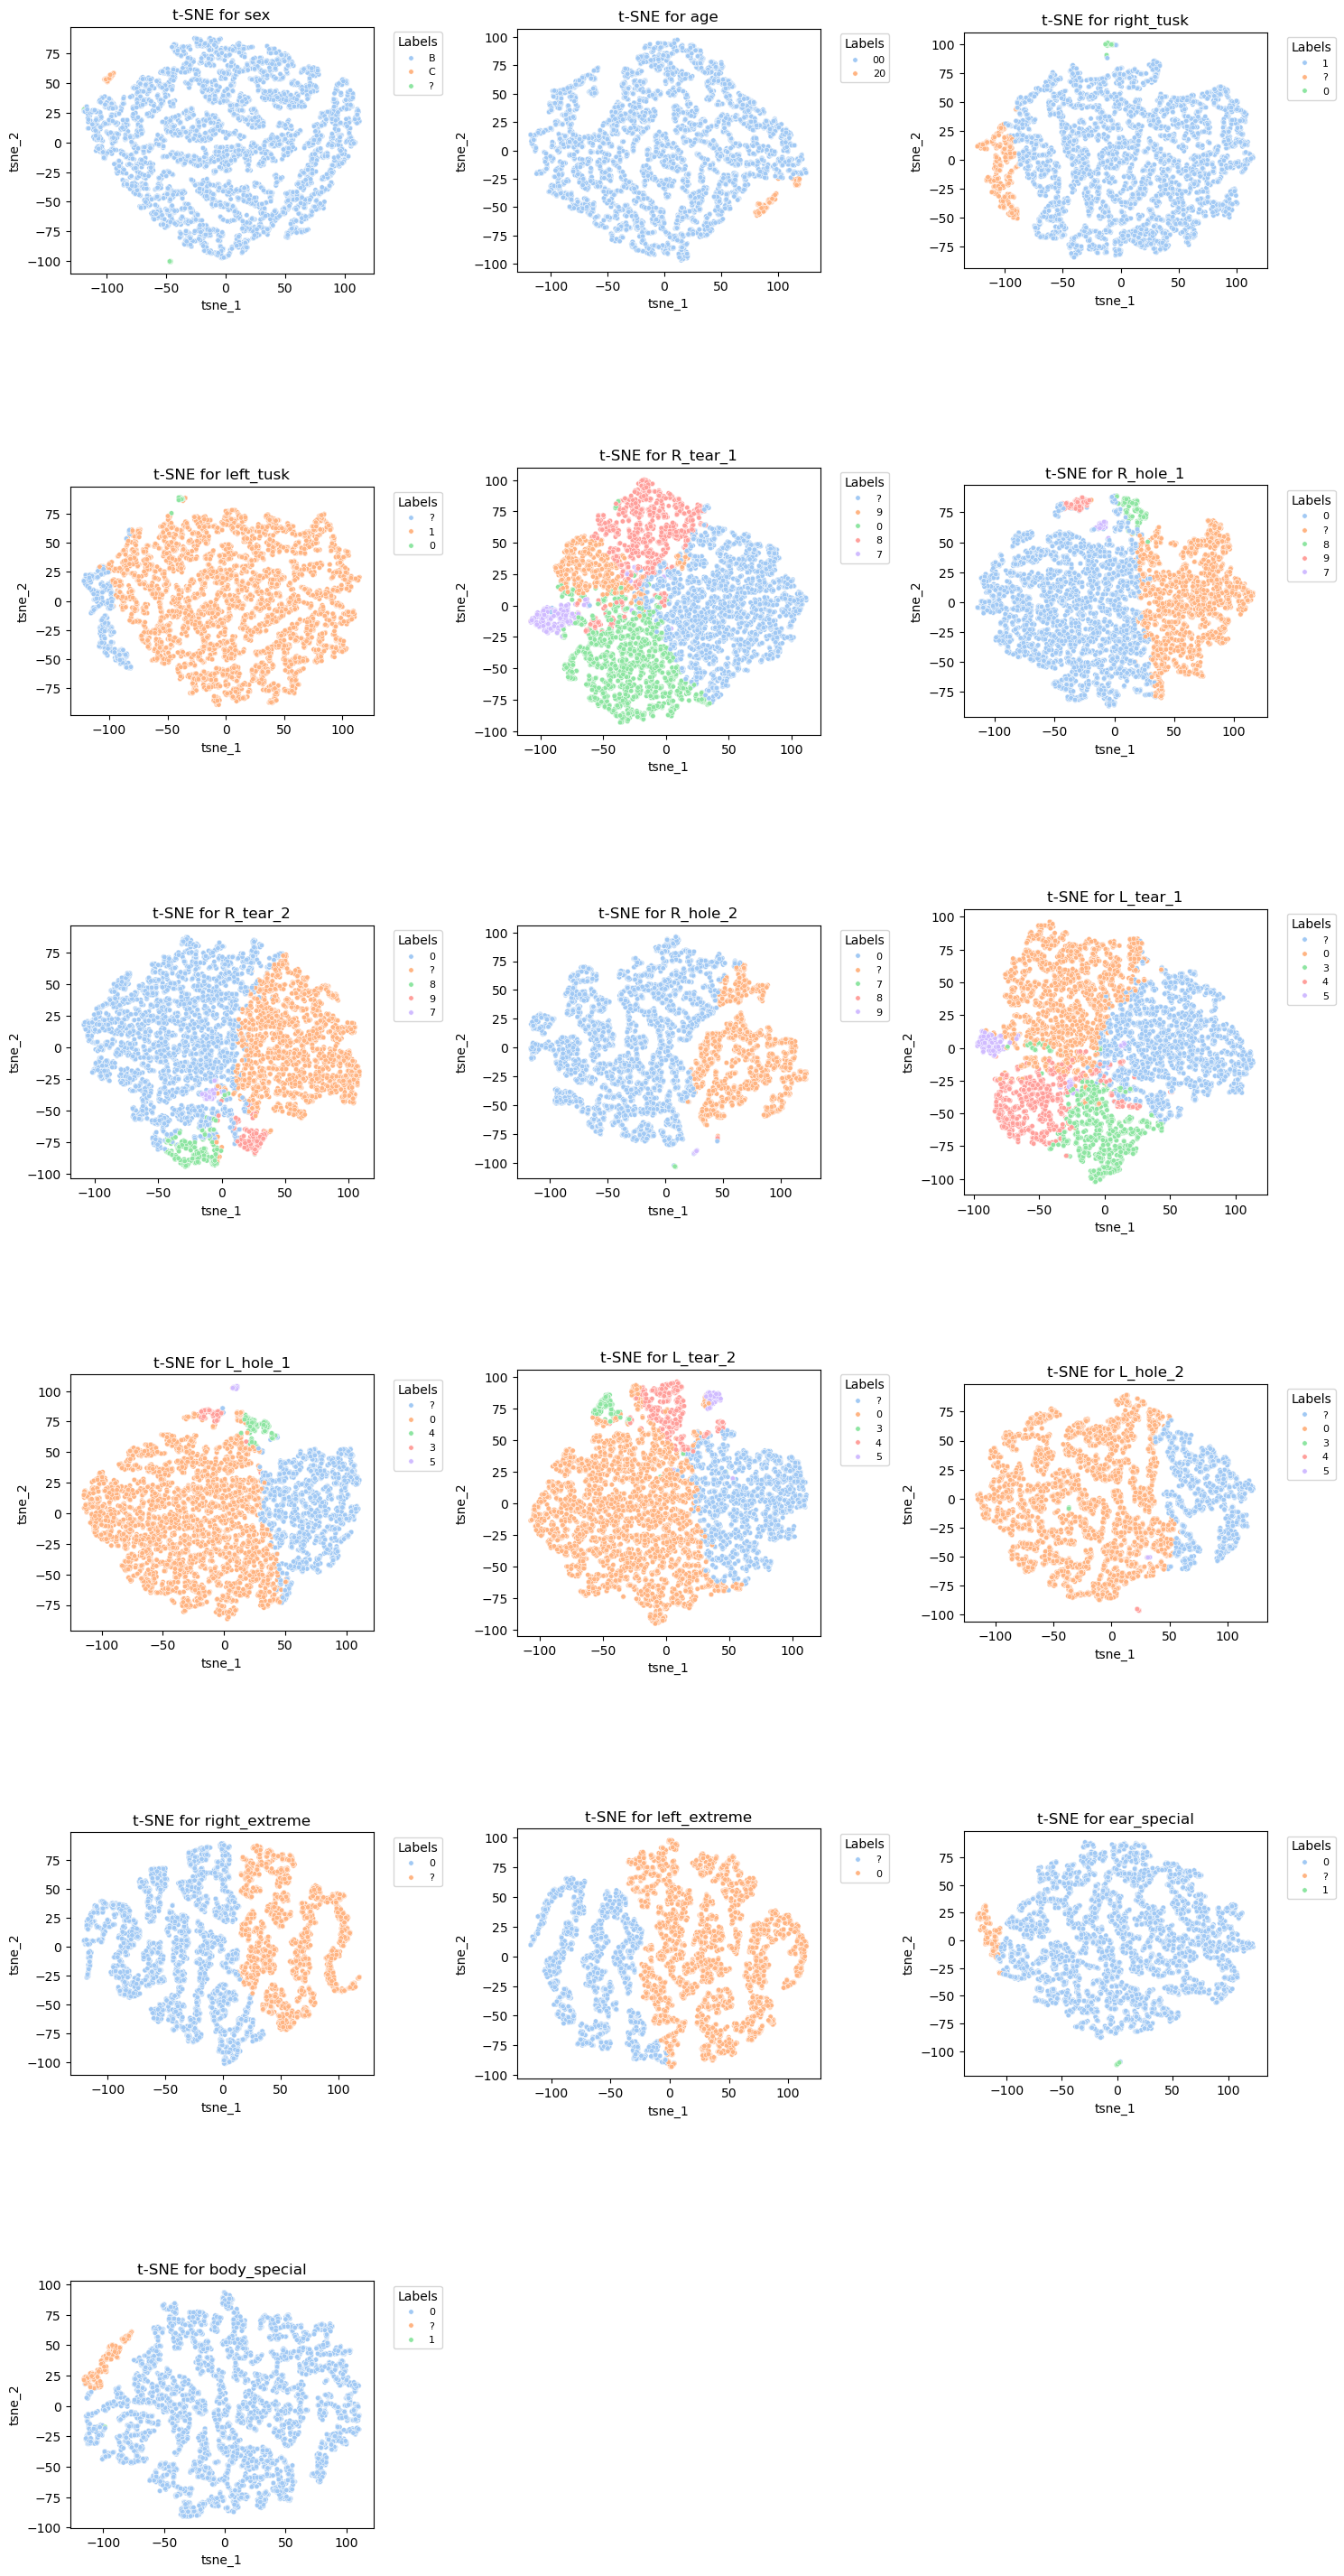

In [122]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE



# Prepare grid dimensions
num_attributes = len(SEEK.attribute_names)
num_cols = 3
num_rows = (num_attributes + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, num_rows * 5))

# Loop through attributes
for i, attribute in enumerate(SEEK.attribute_names):

    # Perform t-SNE
    tsne = TSNE(n_components=2, perplexity=15, random_state=42)
    tsne_result = tsne.fit_transform(val_prob_list[i])

    # Get labels for coloring
    y = [getattr(SEEK(predictions[j]), attribute) for j in range(len(predictions))]

    # Create a DataFrame for plotting
    tsne_result_df = pd.DataFrame({'tsne_1': tsne_result[:, 0], 'tsne_2': tsne_result[:, 1], 'label': y})
    # Replace "_" with "Underscore" or similar
    tsne_result_df['label'] = tsne_result_df['label'].replace("_", "?")


    # Plot scatterplot
    ax = axes[i // num_cols, i % num_cols]
    sns.scatterplot(
        x='tsne_1', 
        y='tsne_2', 
        hue='label', 
        data=tsne_result_df, 
        ax=ax, 
        s=15, 
        palette='pastel'  # Customize palette as needed
    )
    ax.set_title(f't-SNE for {attribute}', fontsize=12)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Labels', fontsize=8)
    ax.set_aspect('equal')



# Remove unused subplots
for j in range(num_attributes, num_rows * num_cols):
    fig.delaxes(axes[j // num_cols, j % num_cols])

# Tight layout for neat display
plt.tight_layout()
plt.show()


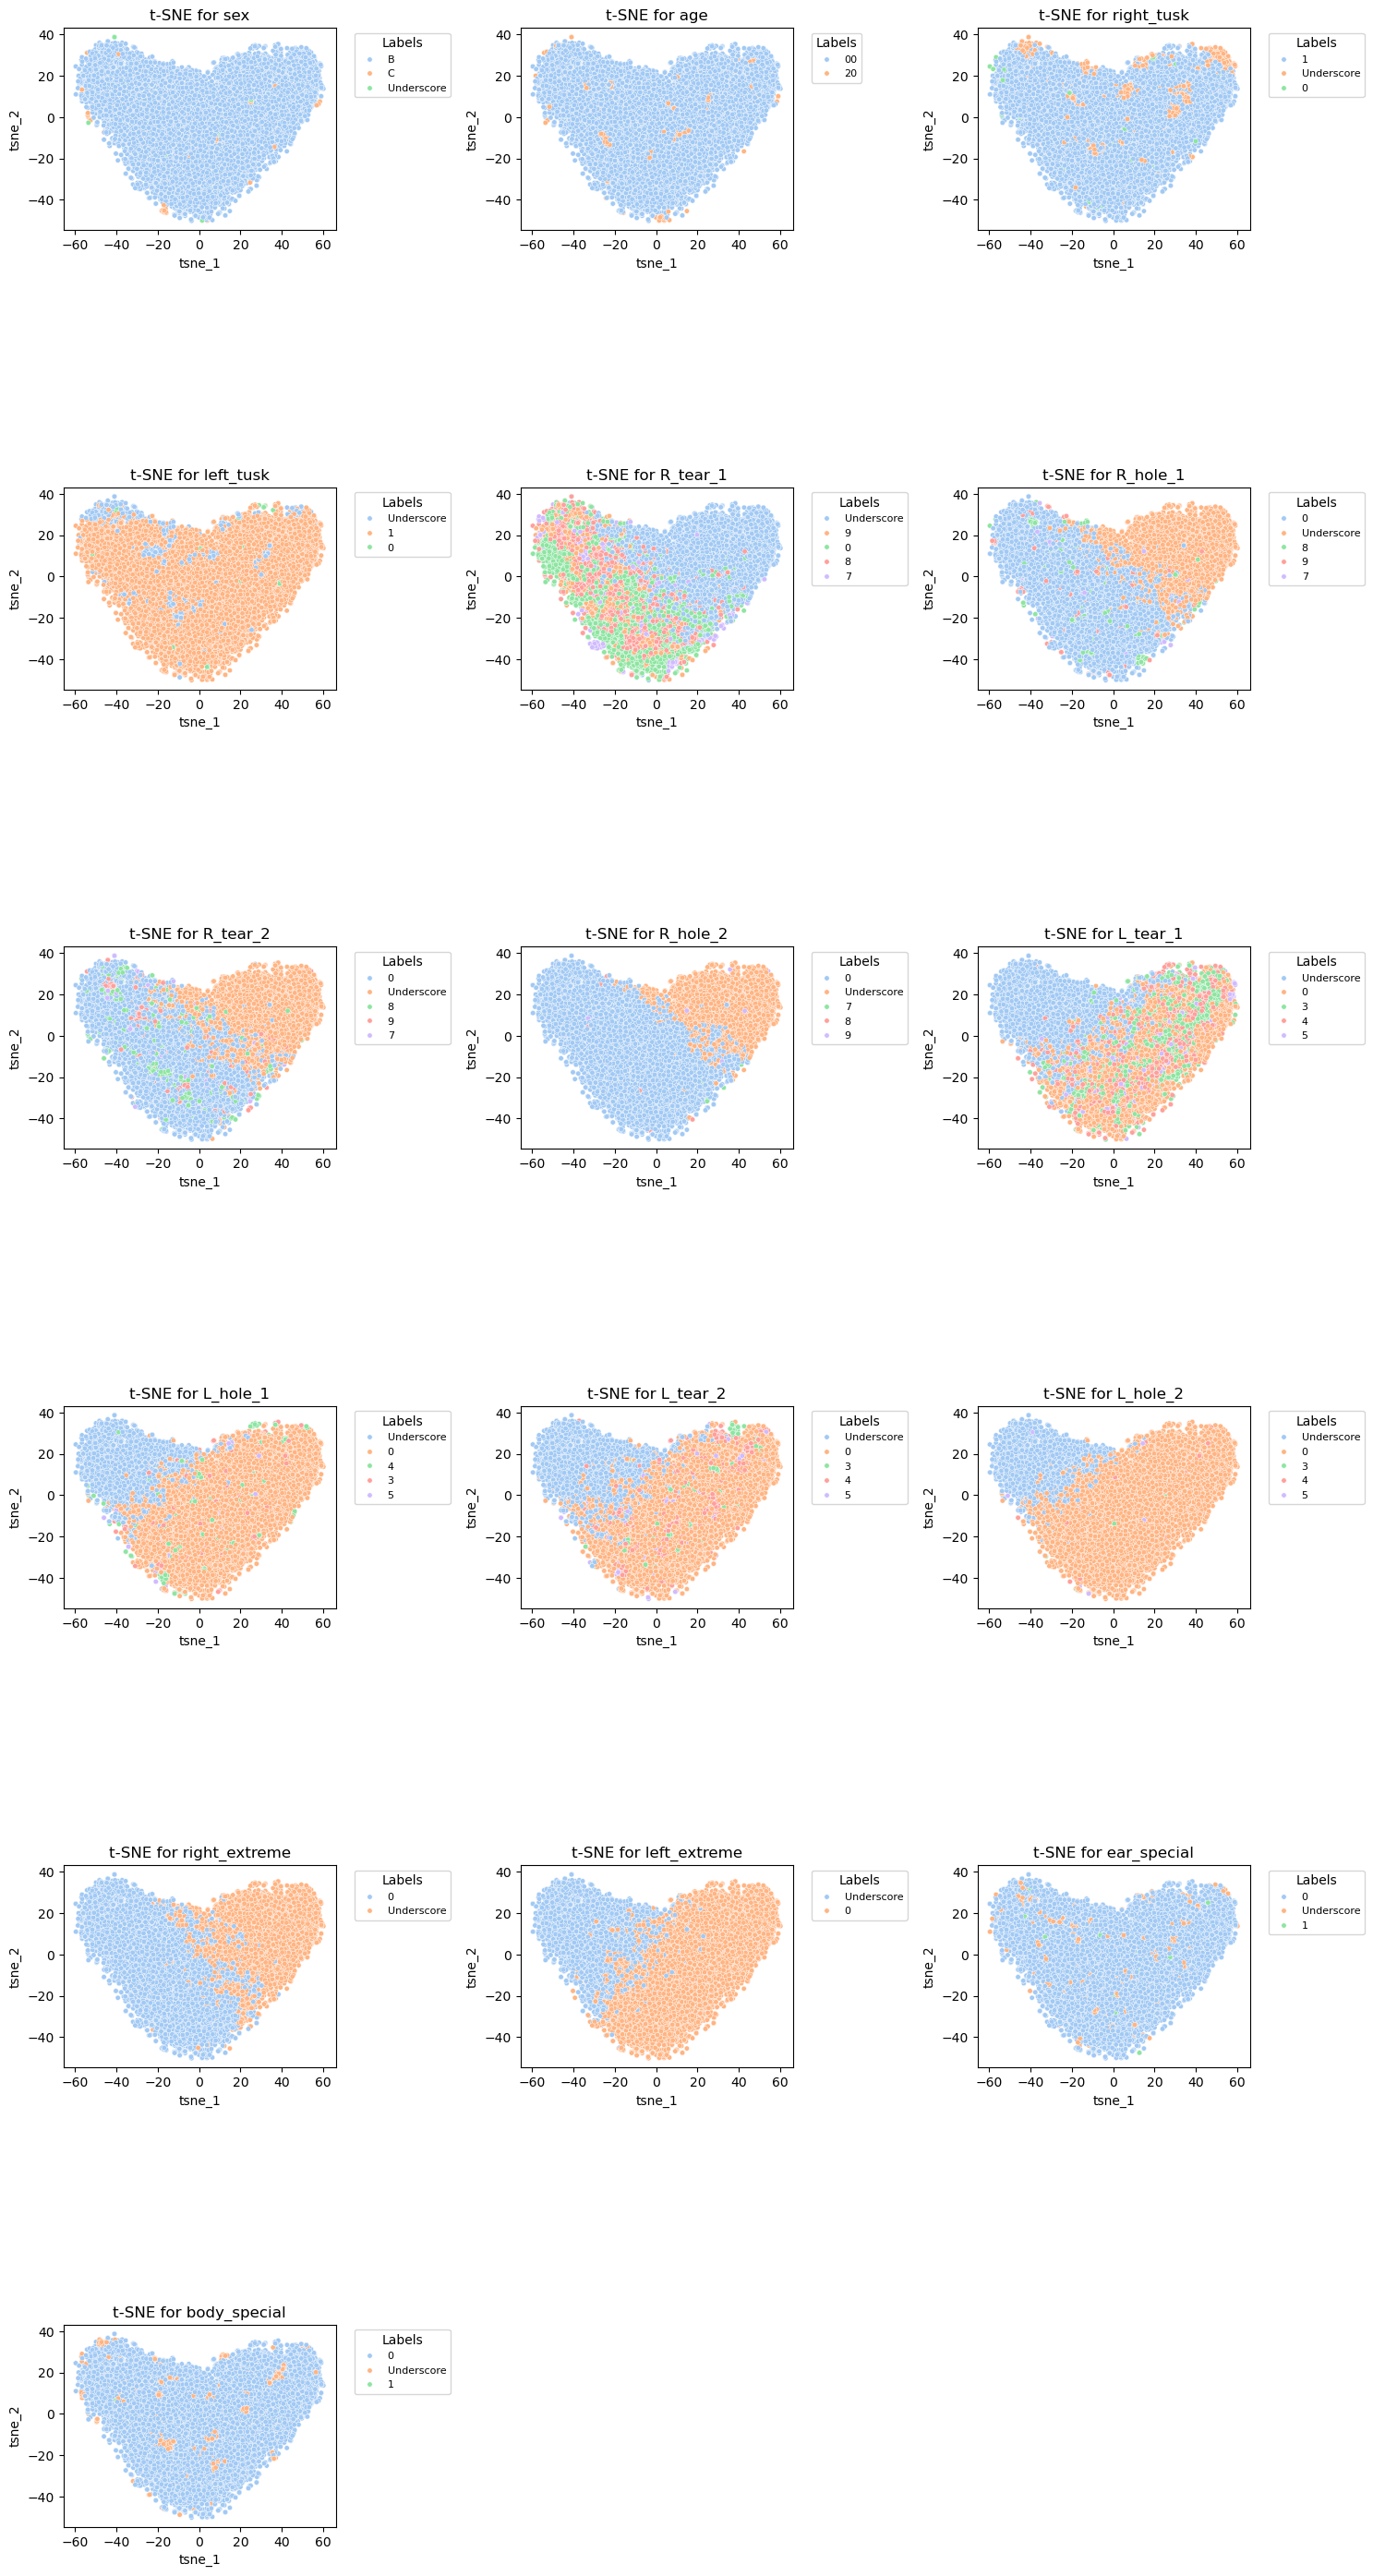

In [123]:
# Prepare grid dimensions
num_attributes = len(SEEK.attribute_names)
num_cols = 3
num_rows = (num_attributes + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, num_rows * 5))
# Perform t-SNE
tsne = TSNE(n_components=2, perplexity=50, random_state=42)
tsne_result = tsne.fit_transform(outputs)

# Loop through attributes
for i, attribute in enumerate(SEEK.attribute_names):


    # Get labels for coloring
    y = [getattr(SEEK(predictions[j]), attribute) for j in range(len(predictions))]

    # Create a DataFrame for plotting
    tsne_result_df = pd.DataFrame({'tsne_1': tsne_result[:, 0], 'tsne_2': tsne_result[:, 1], 'label': y})
    # Replace "_" with "Underscore" or similar
    tsne_result_df['label'] = tsne_result_df['label'].replace("_", "Underscore")


    # Plot scatterplot
    ax = axes[i // num_cols, i % num_cols]
    sns.scatterplot(
        x='tsne_1', 
        y='tsne_2', 
        hue='label', 
        data=tsne_result_df, 
        ax=ax, 
        s=15, 
        palette='pastel'  # Customize palette as needed
    )
    ax.set_title(f't-SNE for {attribute}', fontsize=12)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Labels', fontsize=8)
    ax.set_aspect('equal')



# Remove unused subplots
for j in range(num_attributes, num_rows * num_cols):
    fig.delaxes(axes[j // num_cols, j % num_cols])

# Tight layout for neat display
plt.tight_layout()
plt.show()

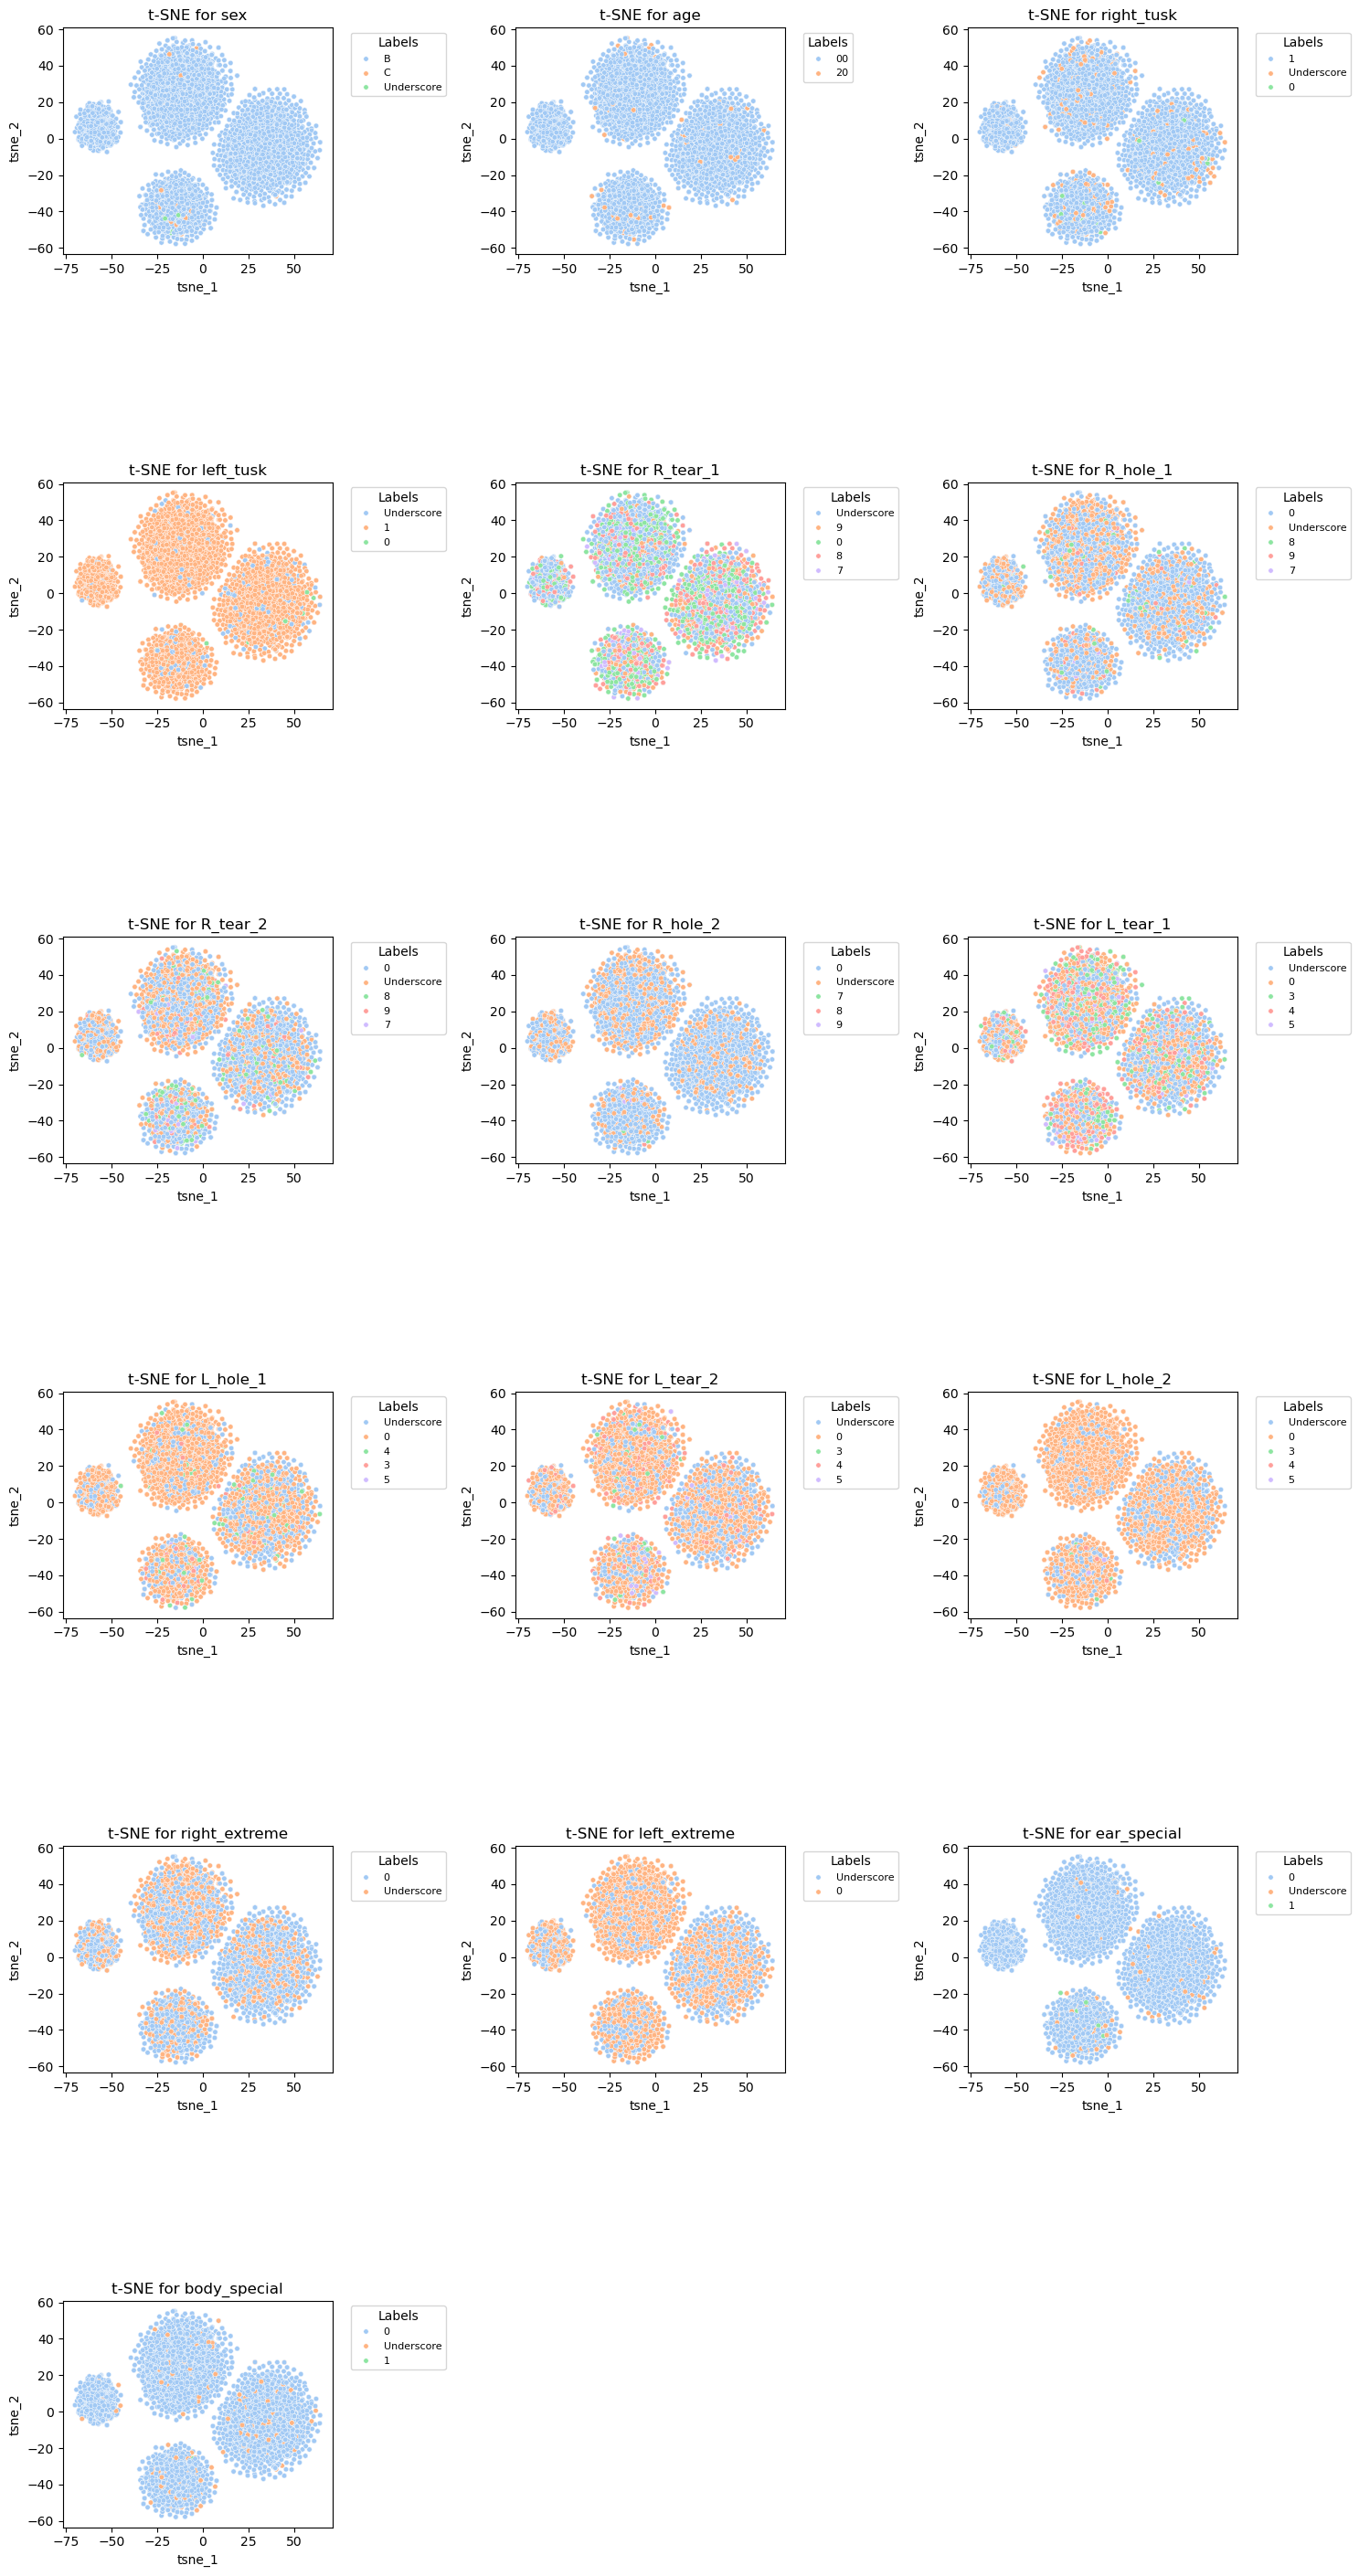

In [124]:
# Prepare grid dimensions
num_attributes = len(SEEK.attribute_names)
num_cols = 3
num_rows = (num_attributes + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, num_rows * 5))
# Perform t-SNE
tsne = TSNE(n_components=2, perplexity=15, random_state=42)
tsne_result = tsne.fit_transform(embeddings)

# Loop through attributes
for i, attribute in enumerate(SEEK.attribute_names):


    # Get labels for coloring
    y = [getattr(SEEK(predictions[j]), attribute) for j in range(len(predictions))]

    # Create a DataFrame for plotting
    tsne_result_df = pd.DataFrame({'tsne_1': tsne_result[:, 0], 'tsne_2': tsne_result[:, 1], 'label': y})
    # Replace "_" with "Underscore" or similar
    tsne_result_df['label'] = tsne_result_df['label'].replace("_", "Underscore")


    # Plot scatterplot
    ax = axes[i // num_cols, i % num_cols]
    sns.scatterplot(
        x='tsne_1', 
        y='tsne_2', 
        hue='label', 
        data=tsne_result_df, 
        ax=ax, 
        s=15, 
        palette='pastel'  # Customize palette as needed
    )
    ax.set_title(f't-SNE for {attribute}', fontsize=12)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Labels', fontsize=8)
    ax.set_aspect('equal')



# Remove unused subplots
for j in range(num_attributes, num_rows * num_cols):
    fig.delaxes(axes[j // num_cols, j % num_cols])

# Tight layout for neat display
plt.tight_layout()
plt.show()